<a href="https://colab.research.google.com/github/ila21math/black-scholes-mc/blob/main/options_pricing_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Options Pricing, Greeks & Implied Volatility
**Ila Sharma**

This notebook implements:
1. Black-Scholes closed-form pricing for European call and put options
2. Option Greeks (Delta, Gamma, Vega, Theta, Rho)
3. Monte Carlo simulation via Geometric Brownian Motion with convergence analysis
4. Implied Volatility extraction from real SPY options market data (via `yfinance`)
5. Volatility Smile / Skew visualisation

---

## 0. Install & Import Dependencies

In [1]:
# Run this cell first to ensure yfinance is available
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance", "-q"])
print("Dependencies ready.")

Dependencies ready.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("All imports successful.")

All imports successful.


## 1. Base Contract Parameters

In [3]:
S0    = 100.0    # Current stock price (normalised for analytical sections)
K     = 100.0    # Strike price — at-the-money
T     = 1.0      # Time to expiry in years
r     = 0.05     # Risk-free rate (annualised) — approximate 1yr US T-bill
sigma = 0.20     # Volatility (annualised)
N     = 10_000   # Monte Carlo paths

## 2. Black-Scholes Analytical Pricing

Under risk-neutral GBM dynamics, the closed-form prices for European options are:

$$d_1 = \frac{\ln(S/K)+(r+\frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

$$C = S\,N(d_1) - Ke^{-rT}N(d_2), \qquad P = Ke^{-rT}N(-d_2) - S\,N(-d_1)$$

In [4]:
def black_scholes(S, K, T, r, sigma, option_type="call"):
    """
    Black-Scholes price for a European call or put.
    Handles arrays for S, K, or sigma for vectorised sensitivity analysis.
    """
    # Guard: return intrinsic value when T is effectively zero
    if np.isscalar(T) and T <= 0:
        if option_type == "call":
            return np.maximum(S - K, 0)
        return np.maximum(K - S, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


bs_call = black_scholes(S0, K, T, r, sigma, "call")
bs_put  = black_scholes(S0, K, T, r, sigma, "put")

print(f"Black-Scholes Call : ${bs_call:.4f}")
print(f"Black-Scholes Put  : ${bs_put:.4f}")

# Put-call parity verification: C - P = S - K*e^(-rT)
lhs = bs_call - bs_put
rhs = S0 - K * np.exp(-r * T)
print(f"\nPut-Call Parity    : {lhs:.6f} == {rhs:.6f}  ",
      "PASS" if abs(lhs - rhs) < 1e-8 else "FAIL")

Black-Scholes Call : $10.4506
Black-Scholes Put  : $5.5735

Put-Call Parity    : 4.877058 == 4.877058   PASS


## 3. Option Greeks

In [5]:
def compute_greeks(S, K, T, r, sigma):
    """
    Returns a dict of all five standard Greeks for call and put.
    Vega and Rho are scaled per 1% move (divided by 100).
    Theta is scaled to daily decay (divided by 365).
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta_call =  norm.cdf(d1)
    delta_put  =  delta_call - 1
    gamma      =  norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega       =  S * norm.pdf(d1) * np.sqrt(T) / 100
    theta_call = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                  - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    theta_put  = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                  + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
    rho_call   =  K * T * np.exp(-r * T) * norm.cdf(d2)  / 100
    rho_put    = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100

    return {
        "Delta (call)" : delta_call, "Delta (put)"  : delta_put,
        "Gamma"        : gamma,      "Vega (per 1%)": vega,
        "Theta/day (call)": theta_call, "Theta/day (put)": theta_put,
        "Rho (per 1%) call": rho_call, "Rho (per 1%) put": rho_put
    }


g = compute_greeks(S0, K, T, r, sigma)
df_greeks = pd.DataFrame(g.items(), columns=["Greek", "Value"])
df_greeks["Value"] = df_greeks["Value"].round(6)
print(df_greeks.to_string(index=False))

            Greek     Value
     Delta (call)  0.636831
      Delta (put) -0.363169
            Gamma  0.018762
    Vega (per 1%)  0.375240
 Theta/day (call) -0.017573
  Theta/day (put) -0.004542
Rho (per 1%) call  0.532325
 Rho (per 1%) put -0.418905


## 4. Monte Carlo Simulation via Geometric Brownian Motion

Under the risk-neutral measure, the terminal stock price is:

$$S_T = S_0 \exp\!\left[(r - \tfrac{\sigma^2}{2})T + \sigma\sqrt{T}\,Z\right], \quad Z \sim \mathcal{N}(0,1)$$

The option price is the discounted expected payoff: $\,e^{-rT}\,\mathbb{E}[\max(S_T - K,\,0)]$

In [6]:
def monte_carlo_price(S, K, T, r, sigma, N, option_type="call"):
    """
    Monte Carlo European option pricer.
    Returns: (price, standard_error, terminal_prices)
    """
    Z  = np.random.standard_normal(N)
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    payoffs = np.maximum(ST - K, 0) if option_type == "call" else np.maximum(K - ST, 0)
    pv      = np.exp(-r * T) * payoffs

    return pv.mean(), pv.std() / np.sqrt(N), ST


mc_call, se_call, ST = monte_carlo_price(S0, K, T, r, sigma, N, "call")
mc_put,  se_put,  _  = monte_carlo_price(S0, K, T, r, sigma, N, "put")

print(f"MC Call  : ${mc_call:.4f}  SE={se_call:.4f}  |  BS=${bs_call:.4f}  |  Error=${abs(mc_call-bs_call):.4f}")
print(f"MC Put   : ${mc_put:.4f}  SE={se_put:.4f}  |  BS=${bs_put:.4f}  |  Error=${abs(mc_put-bs_put):.4f}")

MC Call  : $10.4502  SE=0.1478  |  BS=$10.4506  |  Error=$0.0004
MC Put   : $5.4598  SE=0.0859  |  BS=$5.5735  |  Error=$0.1137


## 5. Monte Carlo Convergence Analysis

MC error decreases at rate $1/\sqrt{N}$ — quadrupling paths halves the error.

In [7]:
path_counts = [100, 500, 1_000, 2_000, 5_000, 10_000, 25_000, 50_000]
mc_prices, mc_errors, mc_ses = [], [], []

for n in path_counts:
    price, se, _ = monte_carlo_price(S0, K, T, r, sigma, n, "call")
    mc_prices.append(price)
    mc_errors.append(abs(price - bs_call))
    mc_ses.append(se)

df_conv = pd.DataFrame({
    "Paths"    : path_counts,
    "MC Price" : np.round(mc_prices, 4),
    "Abs Error": np.round(mc_errors, 4),
    "Std Error": np.round(mc_ses,    4)
})
print(df_conv.to_string(index=False))

 Paths  MC Price  Abs Error  Std Error
   100   10.4552     0.0046     1.4365
   500    9.9503     0.5003     0.6556
  1000   10.4605     0.0100     0.4539
  2000   10.3125     0.1381     0.3272
  5000   10.2014     0.2492     0.2031
 10000   10.2695     0.1810     0.1457
 25000   10.6165     0.1660     0.0935
 50000   10.4807     0.0301     0.0659


## 6. Implied Volatility from Real SPY Market Data

Black-Scholes can be **inverted**: given a real market option price, we solve numerically for the volatility $\hat{\sigma}$ that equates the model price to the observed price. This $\hat{\sigma}$ is the **implied volatility (IV)** — the market's forward-looking estimate of uncertainty.

We use **Brent's method** (`scipy.optimize.brentq`), a robust root-finding algorithm, to solve:

$$\text{BS}(S, K, T, r, \hat{\sigma}) - \text{Market Price} = 0$$

Data source: SPY options chain pulled live from Yahoo Finance via `yfinance`.

In [8]:
def implied_vol(market_price, S, K, T, r, option_type="call",
                vol_low=1e-4, vol_high=5.0, tol=1e-6):
    """
    Compute implied volatility via Brent's root-finding method.

    Brent's method brackets the root between vol_low and vol_high,
    then converges using a combination of bisection and interpolation.
    Returns NaN if no solution exists in the bracket (e.g. deep ITM/OTM
    options with very low liquidity).
    """
    objective = lambda vol: black_scholes(S, K, T, r, vol, option_type) - market_price

    try:
        # Check bracket is valid (signs must differ at endpoints)
        if objective(vol_low) * objective(vol_high) > 0:
            return np.nan
        return brentq(objective, vol_low, vol_high, xtol=tol)
    except (ValueError, RuntimeError):
        return np.nan


# ── Pull live SPY data ────────────────────────────────────────────────────────
print("Fetching SPY data from Yahoo Finance...")
spy = yf.Ticker("SPY")
S_spy = spy.history(period="1d")["Close"].iloc[-1]
print(f"SPY spot price: ${S_spy:.2f}")

# Pick the nearest expiry that is at least 20 days out
from datetime import datetime, timedelta
today = datetime.today()
expiry = None
for exp_str in spy.options:
    exp_dt = datetime.strptime(exp_str, "%Y-%m-%d")
    if (exp_dt - today).days >= 20:
        expiry = exp_str
        break

print(f"Using expiry: {expiry}")
T_spy = (datetime.strptime(expiry, "%Y-%m-%d") - today).days / 365
r_spy = 0.05   # approximate risk-free rate

chain = spy.option_chain(expiry)
calls = chain.calls.copy()

# Filter to liquid near-the-money options:
# keep strikes within ±15% of spot, volume > 10, valid mid price
calls = calls[
    (calls["strike"] >= S_spy * 0.85) &
    (calls["strike"] <= S_spy * 1.15) &
    (calls["volume"] > 10)
].copy()

calls["mid_price"] = (calls["bid"] + calls["ask"]) / 2
calls = calls[calls["mid_price"] > 0.05].copy()

print(f"Retained {len(calls)} liquid near-the-money call contracts.")

Fetching SPY data from Yahoo Finance...
SPY spot price: $672.38
Using expiry: 2026-03-31
Retained 73 liquid near-the-money call contracts.


In [9]:
# Compute implied vol for each retained strike
calls["implied_vol"] = calls.apply(
    lambda row: implied_vol(
        market_price=row["mid_price"],
        S=S_spy,
        K=row["strike"],
        T=T_spy,
        r=r_spy,
        option_type="call"
    ), axis=1
)

# Drop strikes where IV could not be solved
calls = calls.dropna(subset=["implied_vol"])
calls["moneyness"] = calls["strike"] / S_spy   # K/S ratio — 1.0 = ATM

# Display summary
display_cols = ["strike", "mid_price", "volume", "implied_vol", "moneyness"]
df_iv = calls[display_cols].copy()
df_iv["implied_vol"] = (df_iv["implied_vol"] * 100).round(2)
df_iv["moneyness"]   = df_iv["moneyness"].round(4)
df_iv.columns       = ["Strike", "Mid Price", "Volume", "Impl. Vol (%)", "Moneyness (K/S)"]
print(df_iv.to_string(index=False))

 Strike  Mid Price  Volume  Impl. Vol (%)  Moneyness (K/S)
  600.0     75.830   300.0          32.69           0.8924
  615.0     61.980    16.0          31.24           0.9147
  620.0     57.690    37.0          31.33           0.9221
  622.0     55.685    12.0          30.46           0.9251
  628.0     50.410    75.0          29.78           0.9340
  640.0     40.220    34.0          28.27           0.9518
  641.0     39.370    47.0          28.08           0.9533
  646.0     35.315    12.0          27.40           0.9608
  650.0     32.090    49.0          26.70           0.9667
  655.0     28.290    18.0          26.01           0.9742
  660.0     23.995    32.0          24.23           0.9816
  665.0     20.335    14.0          23.22           0.9890
  667.0     20.020    30.0          24.52           0.9920
  668.0     19.410    16.0          24.43           0.9935
  669.0     18.105   196.0          23.26           0.9950
  670.0     17.440   667.0          23.07           0.99

## 7. Visualisations

In [10]:
# ── Pre-compute sensitivity arrays ────────────────────────────────────────────
strikes_range = np.linspace(60, 140, 200)
vols_range    = np.linspace(0.05, 0.60, 200)

deltas_k = [compute_greeks(S0, k, T, r, sigma)["Delta (call)"] for k in strikes_range]
gammas_k = [compute_greeks(S0, k, T, r, sigma)["Gamma"]        for k in strikes_range]
call_vs_vol = [black_scholes(S0, K, T, r, v, "call") for v in vols_range]
put_vs_vol  = [black_scholes(S0, K, T, r, v, "put")  for v in vols_range]

# ── GBM paths ─────────────────────────────────────────────────────────────────
n_display = 200
t_grid    = np.linspace(0, T, 252)
dt        = T / 252
Z_paths   = np.random.standard_normal((n_display, 252))
log_ret   = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_paths
paths     = S0 * np.exp(np.cumsum(log_ret, axis=1))
paths     = np.hstack([np.full((n_display, 1), S0), paths])

print("Sensitivity arrays ready.")

Sensitivity arrays ready.


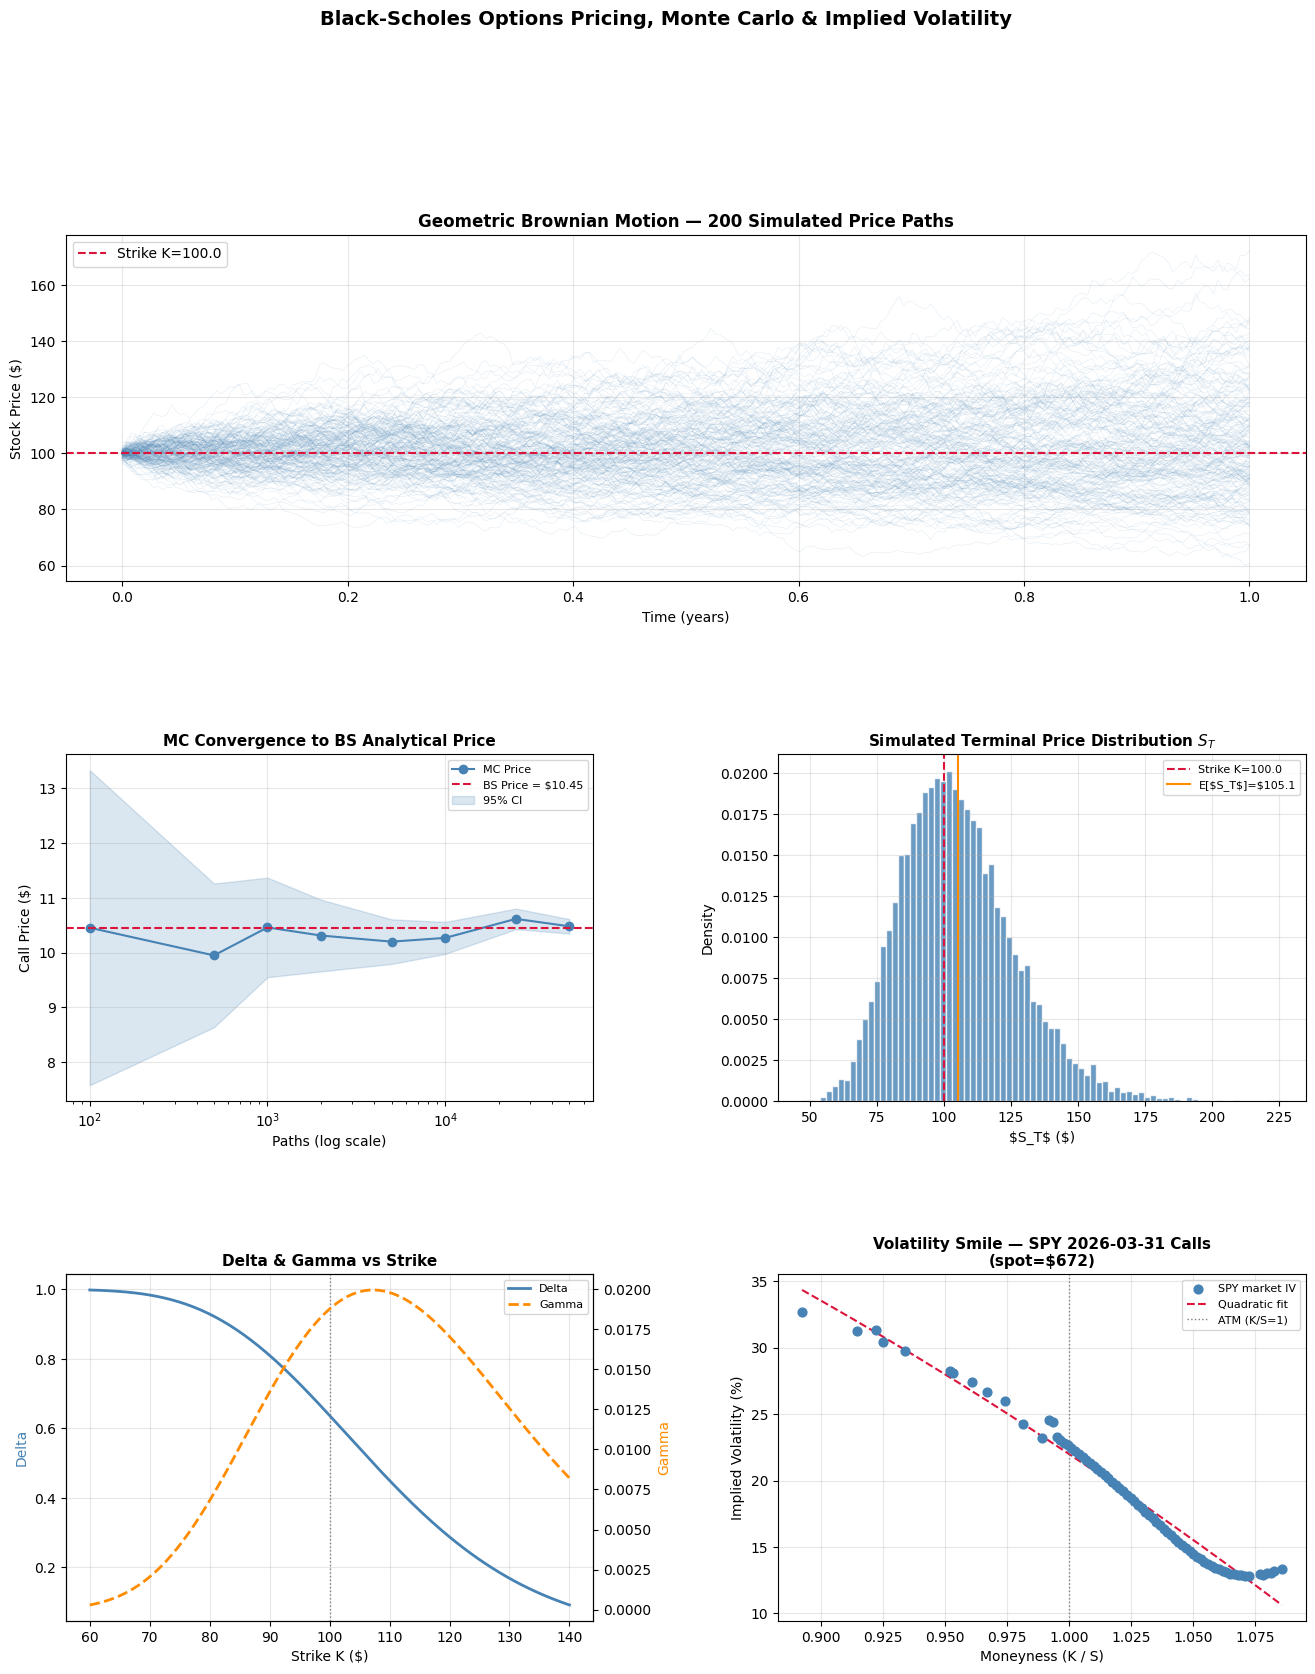

Figure saved as options_pricing_analysis.png


In [11]:
fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)

# ── Plot 1: GBM paths (full width) ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for i in range(n_display):
    ax1.plot(t_grid, paths[i, 1:], alpha=0.12, linewidth=0.5, color="steelblue")
ax1.axhline(K, color="crimson", linewidth=1.5, linestyle="--", label=f"Strike K={K}")
ax1.set_title("Geometric Brownian Motion — 200 Simulated Price Paths",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Time (years)"); ax1.set_ylabel("Stock Price ($)")
ax1.legend(); ax1.grid(alpha=0.3)

# ── Plot 2: MC Convergence ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogx(path_counts, mc_prices, "o-", color="steelblue", label="MC Price")
ax2.axhline(bs_call, color="crimson", linestyle="--",
            label=f"BS Price = ${bs_call:.2f}")
ax2.fill_between(path_counts,
                 [p - 2*s for p, s in zip(mc_prices, mc_ses)],
                 [p + 2*s for p, s in zip(mc_prices, mc_ses)],
                 alpha=0.2, color="steelblue", label="95% CI")
ax2.set_title("MC Convergence to BS Analytical Price",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Paths (log scale)"); ax2.set_ylabel("Call Price ($)")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Plot 3: Terminal Distribution ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(ST, bins=80, color="steelblue", edgecolor="white", alpha=0.8, density=True)
ax3.axvline(K,        color="crimson",     linewidth=1.5, linestyle="--",
            label=f"Strike K={K}")
ax3.axvline(ST.mean(), color="darkorange", linewidth=1.5,
            label=f"E[$S_T$]=${ST.mean():.1f}")
ax3.set_title("Simulated Terminal Price Distribution $S_T$",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("$S_T$ ($)"); ax3.set_ylabel("Density")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# ── Plot 4: Delta & Gamma vs Strike ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4b = ax4.twinx()
ax4.plot(strikes_range, deltas_k, color="steelblue",  linewidth=2, label="Delta")
ax4b.plot(strikes_range, gammas_k, color="darkorange", linewidth=2,
          linestyle="--", label="Gamma")
ax4.axvline(S0, color="grey", linestyle=":", linewidth=1)
ax4.set_title("Delta & Gamma vs Strike", fontsize=11, fontweight="bold")
ax4.set_xlabel("Strike K ($)")
ax4.set_ylabel("Delta",  color="steelblue")
ax4b.set_ylabel("Gamma", color="darkorange")
h1, l1 = ax4.get_legend_handles_labels()
h2, l2 = ax4b.get_legend_handles_labels()
ax4.legend(h1 + h2, l1 + l2, fontsize=8)
ax4.grid(alpha=0.3)

# ── Plot 5: Volatility Smile (real SPY IV) ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(calls["moneyness"],
            calls["implied_vol"] * 100,
            color="steelblue", s=40, zorder=3, label="SPY market IV")

# Fit a quadratic to the smile for the trendline
if len(calls) >= 3:
    poly_coeffs = np.polyfit(calls["moneyness"], calls["implied_vol"] * 100, 2)
    mono_fit    = np.linspace(calls["moneyness"].min(), calls["moneyness"].max(), 200)
    iv_fit      = np.polyval(poly_coeffs, mono_fit)
    ax5.plot(mono_fit, iv_fit, color="crimson", linewidth=1.5,
             linestyle="--", label="Quadratic fit")

ax5.axvline(1.0, color="grey", linestyle=":", linewidth=1, label="ATM (K/S=1)")
ax5.set_title(f"Volatility Smile — SPY {expiry} Calls\n(spot=${S_spy:.0f})",
              fontsize=11, fontweight="bold")
ax5.set_xlabel("Moneyness (K / S)")
ax5.set_ylabel("Implied Volatility (%)")
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

plt.suptitle("Black-Scholes Options Pricing, Monte Carlo & Implied Volatility",
             fontsize=14, fontweight="bold", y=1.005)
plt.savefig("options_pricing_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as options_pricing_analysis.png")

## 8. Summary Table

In [12]:
summary = pd.DataFrame({
    "Method"    : ["Black-Scholes (Analytical)", f"Monte Carlo (N={N:,})"],
    "Call Price": [round(bs_call, 4), round(mc_call, 4)],
    "Put Price" : [round(bs_put,  4), round(mc_put,  4)],
    "Call Error": ["—", round(abs(mc_call - bs_call), 4)],
    "Put Error" : ["—", round(abs(mc_put  - bs_put),  4)]
})
print(summary.to_string(index=False))

print(f"\nSPY Implied Volatility Summary (expiry {expiry}):")
print(f"  Contracts analysed : {len(calls)}")
print(f"  IV range           : {calls['implied_vol'].min()*100:.1f}% — {calls['implied_vol'].max()*100:.1f}%")
print(f"  ATM IV (near K/S=1): {calls.iloc[(calls['moneyness']-1).abs().argsort()[:1]]['implied_vol'].values[0]*100:.2f}%")

                    Method  Call Price  Put Price Call Error Put Error
Black-Scholes (Analytical)     10.4506     5.5735          —         —
    Monte Carlo (N=10,000)     10.4502     5.4598     0.0004    0.1137

SPY Implied Volatility Summary (expiry 2026-03-31):
  Contracts analysed : 73
  IV range           : 12.8% — 32.7%
  ATM IV (near K/S=1): 22.64%
